In [2]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint

os.chdir("/home/wergillius/Project/PINN_dynamics")

In [3]:
# CHANG THIS !!!!!
# ckpt_path = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/pde_params/lightning_logs/version_5/checkpoints/epoch=180-total_loss=7.75103807.ckpt"
ckpt_path = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/pde_neighborloss/lightning_logs/version_3/checkpoints/epoch=204-total_loss=170.45581055.ckpt"
# ckpt_path = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/pde_neighborloss/lightning_logs/version_4/checkpoints/epoch=237-total_loss=36.90247726.ckpt"

In [4]:
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

In [7]:
pde_model = model_class.load_from_checkpoint(ckpt_path,map_location='cuda:1')

# load data

In [10]:
# MODEL CLASS and define model
# pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].replace("_multiBnch", "")

n_timepoint = 5
n_grid = 50


In [11]:
# the DS
DS_t7 = reader.TwoTimepoint_MeshGrid(AnnData=adata, 
                                resampling_indensity=0.3, 
                                resampling_rate=0.3,
                                n_timepoint = n_timepoint,
                                cellstate_key=cellstate_key,  #'Actb_Kcnn4_scaled_S'
                                n_grid=n_grid,  
                                nearby_cellstate=1, 
                                collocation_points=300, 
                                log_transform=False,
                                norm_time = False,
                                n_repeat=2
                              )


In [12]:
# adata
t7_ad = DS_t7.adata.copy()
u_b = DS_t7.u_b
cellstate = torch.from_numpy(DS_t7.cellstate).float().requires_grad_()

In [15]:
u_b.shape

(5, 2500)

# prediction

In [18]:
if "u" in dir(pde_model):
    u_pred_ls = []
    chunk_size= 500

    s_ts = DS_t7.s.float().to(device)
    t_ts = torch.from_numpy(DS_t7.t_b).float().to(device)

    print(t_ts.shape)
    with torch.no_grad():
        for i in tqdm(range(0, len(t_ts))):
            u_pred = pde_model(s_ts,  t_ts[i])
            u_pred_ls.append(u_pred.detach().cpu().numpy())
    u_pred_b = np.concatenate(u_pred_ls, axis=0).reshape(n_timepoint,-1)

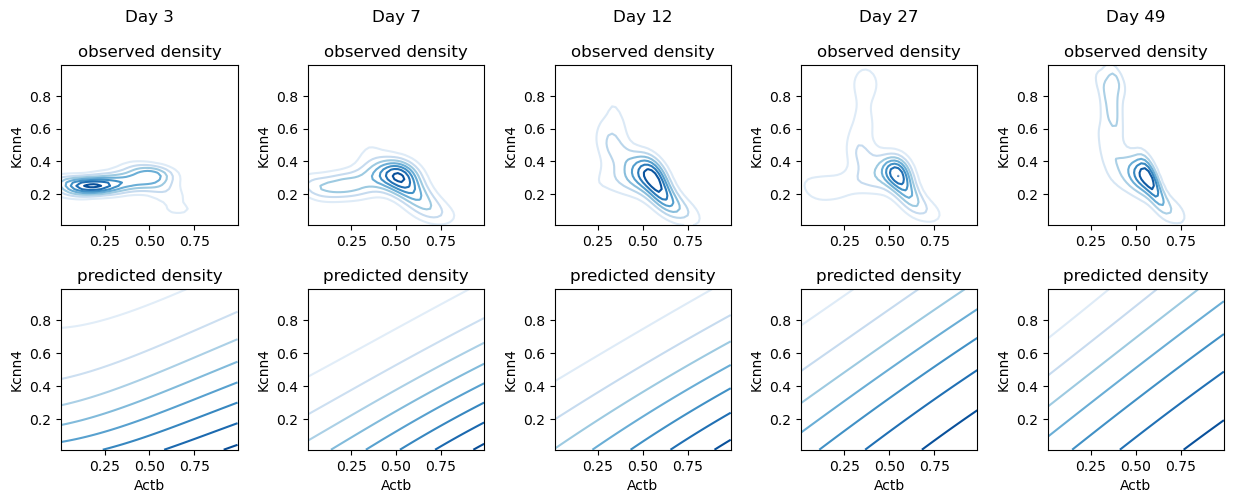

In [62]:
PINN.pl.meshgrid_density_by_time(u_b, u_pred_b, DS_t7, 'Actb', 'Kcnn4');

## simulation

In [19]:
timepoints = timepoints[:n_timepoint]

In [21]:
## predict u with ode integrat
u_int_all = [u_b[0]]
chunk_size= 500
# t_list = timepoints / 15
it = 0
for t0, t1 in tqdm(zip(DS_t7.T_b[:-1], DS_t7.T_b[1:])):
    t0 = t0 / 5
    t1 = t1 / 5
    u_t_ls = []

    for i in range(0, len(cellstate), chunk_size):

        s0 = cellstate[i:i+chunk_size].to(device)
        tompos_u0 = torch.from_numpy(u_b[it, i:i+chunk_size]).float().to(device).requires_grad_()
        init_condition = (tompos_u0, s0)

        step_size = np.around((t1 - t0)/15, decimals=1).item() 
        step_size = step_size if step_size > 0 else 0.05
        step_size = min(step_size, 0.4)


        u_t, s_t = odeint(
                        pde_model,
                        init_condition,
                        torch.tensor([t0, t1]).type(torch.float32).to(device),
                        atol=1e-8,
                        rtol=1e-8,
                        method='dopri5',
                        # options = {'step_size': step_size}
                    )

        torch.cuda.empty_cache()

        u_t_ls.append(u_t[-1].detach().cpu().numpy())
        del u_t, s_t
        torch.cuda.empty_cache()

    u_int = np.concatenate(u_t_ls)
    
    u_int_all.append(u_int)
    it+=0

0it [00:00, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x500 and 3x32)

In [65]:
DS_t7.T_b / 5

array([0.2       , 0.46666667, 0.8       , 1.8       , 3.26666667])

In [66]:
u_int_all = np.stack(u_int_all)

In [67]:
u_int_all.shape

(5, 2500)

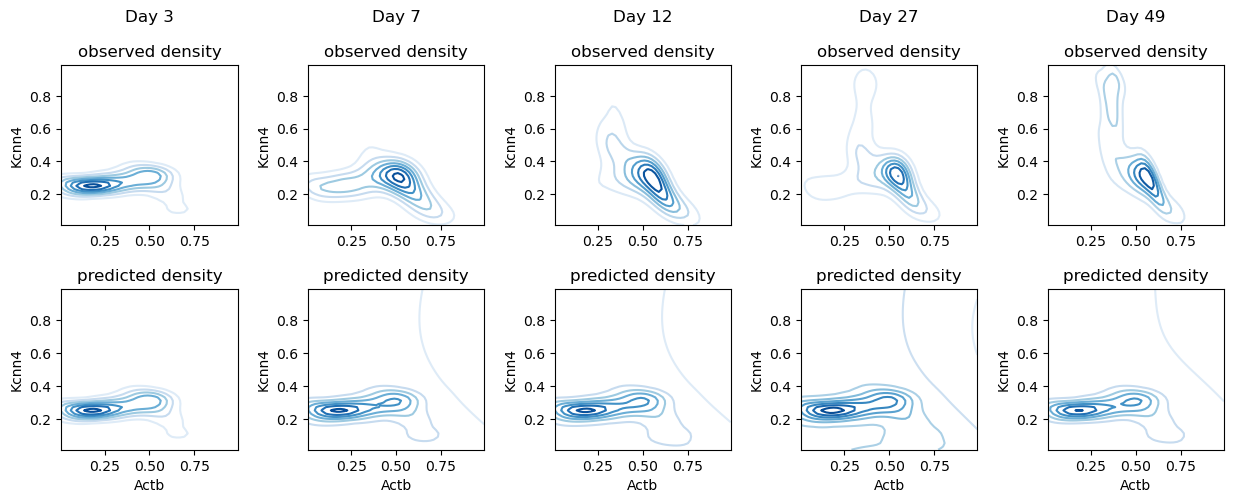

In [68]:
PINN.pl.meshgrid_density_by_time(u_b, u_int_all, DS_t7, 'Actb', 'Kcnn4');